# 🧠 AI-Based Major Depressive Disorder (MDD) Detection from 3D Brain MRI

**King Khalid University | Department of Computer Science | Graduation Project**

**Project Team:** Fahad Al Nahi, Ibrahim Hurubi, Fahad Al-Mubarak, Abdullah Alshaharani, Ali Muyini  
**Supervised by:** Dr. Mohamed Ghouse

---

## Abstract

This notebook presents an end-to-end deep learning pipeline for detecting Major Depressive Disorder (MDD) using structural T1-weighted 3D brain MRI scans and clinical metadata.

The proposed system follows a **State-of-the-Art (SOTA)-inspired multimodal late-fusion framework** by integrating MRI-based anatomical features with clinical variables such as age, sex, education, and HAMD score. A 3D convolutional autoencoder is first pretrained on Healthy Control subjects to learn a normative representation of healthy brain anatomy. The learned encoder is then used as an anatomical blueprint for the final diagnostic model.

The final architecture combines a 3D CNN imaging branch enhanced with Squeeze-and-Excitation attention and a clinical metadata branch based on a Multi-Layer Perceptron (MLP). The fused representation is passed into a binary classification head to distinguish between Healthy Control (HC) and MDD subjects.

To improve robustness and generalization, the training protocol incorporates advanced techniques including multimodal MixUp, label smoothing, focal loss, AdamW optimization, gradient clipping, and cosine annealing learning-rate scheduling.

This pipeline aims to provide an advanced, clinically relevant, and AI-assisted framework for objective depression detection from brain MRI data.

## Phase 1 — Multimodal Data Engineering, Stratification, and Test Set Isolation

### Objective
This cell prepares the final multimodal dataset by combining preprocessed 3D MRI volume paths with clinical metadata. The goal is to create clean training, validation, and independent test sets for the MDD classification task.

### What This Cell Does
- Mounts Google Drive to access the project files.
- Loads the MDD and Healthy Control clinical metadata files.
- Extracts the required clinical features:
  - Sex
  - Age
  - Education
  - HAMD score
- Assigns a HAMD score of `0.0` for Healthy Control subjects.
- Cleans missing clinical values using:
  - Mode for categorical-like values such as Sex
  - Median for continuous variables such as Age, Education, and HAMD
- Loads the master MRI label file containing the MRI volume paths and labels.
- Extracts subject IDs from MRI file names.
- Merges MRI data with clinical metadata using `subject_id`.
- Applies Z-score normalization to continuous clinical variables.
- Splits the dataset into:
  - 80% training set
  - 10% validation set
  - 10% independent test set
- Isolates only Healthy Control samples from the training set for the autoencoder pretraining phase.

### Expected Output
This cell produces four CSV files:
- `train_multimodal.csv`
- `val_multimodal.csv`
- `test_multimodal.csv`
- `healthy_train_only.csv`

### Project Relevance
This phase is essential because it builds the final multimodal dataset used by the model. It also prevents data leakage by keeping the test set completely separate and by using only healthy training samples for the normative autoencoder pretraining phase.

In [ ]:
# ======================================================================================
# CELL 1: Multimodal Data Engineering, Stratification, and Test Set Isolation
# ======================================================================================
from google.colab import drive
import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import train_test_split

drive.mount('/content/drive', force_remount=True)
PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks'
MASTER_OUTPUT_PATH = os.path.join(PROJECT_PATH, 'final_master_labels.csv')

print("Phase 1: Initiating Multimodal Data Engineering Pipeline...\n")

mdd_filename = 'MDD.xlsx'
nc_filename = 'NC.xlsx'

mdd_path = os.path.join(PROJECT_PATH, mdd_filename)
nc_path = os.path.join(PROJECT_PATH, nc_filename)

def load_file(filepath):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Error: File not found at {filepath}. Please ensure the filename and extension are correct.")
    if filepath.endswith('.csv'):
        return pd.read_csv(filepath)
    else:
        return pd.read_excel(filepath)

mdd_df = load_file(mdd_path)
nc_df = load_file(nc_path)

def clean_clinical_data(df, is_mdd=True):
    df_clean = pd.DataFrame()

    if 'ID' in df.columns:
        df_clean['ID'] = df['ID']
    else:
        raise KeyError("Column 'ID' was not found in the clinical file.")

    sex_col = [c for c in df.columns if 'Sex' in c or '性别' in c][0]
    age_col = [c for c in df.columns if 'Age' in c or '年龄' in c][0]
    edu_col = [c for c in df.columns if 'Education' in c or '教育' in c][0]

    df_clean['Sex'] = df[sex_col]
    df_clean['Age'] = df[age_col]
    df_clean['Education'] = df[edu_col]

    if is_mdd:
        hamd_col = [c for c in df.columns if 'HAMD' in c][0]
        df_clean['HAMD'] = df[hamd_col]
    else:
        df_clean['HAMD'] = 0.0

    return df_clean

mdd_clin = clean_clinical_data(mdd_df, is_mdd=True)
nc_clin = clean_clinical_data(nc_df, is_mdd=False)

clinical_master = pd.concat([mdd_clin, nc_clin], ignore_index=True)

for col in ['Sex', 'Age', 'Education', 'HAMD']:
    clinical_master[col] = pd.to_numeric(clinical_master[col], errors='coerce')

clinical_master['Sex'] = clinical_master['Sex'].fillna(clinical_master['Sex'].mode()[0])
clinical_master['Age'] = clinical_master['Age'].fillna(clinical_master['Age'].median())
clinical_master['Education'] = clinical_master['Education'].fillna(clinical_master['Education'].median())
clinical_master['HAMD'] = clinical_master['HAMD'].fillna(0.0)
clinical_master['subject_id'] = clinical_master['ID'].astype(str).str.strip()

master_df = pd.read_csv(MASTER_OUTPUT_PATH)
if 'file_path' in master_df.columns:
    master_df = master_df.rename(columns={'file_path': 'output_npy'})

def extract_id(filepath):
    match = re.search(r'(IS\d+-\d+-\d+)', os.path.basename(filepath))
    return match.group(1) if match else os.path.basename(filepath)

master_df['subject_id'] = master_df['output_npy'].apply(extract_id).astype(str).str.strip()
fused_df = pd.merge(master_df, clinical_master, on='subject_id', how='left')

for col in ['Sex', 'Age', 'Education', 'HAMD']:
    if col == 'Sex':
        fused_df[col] = fused_df[col].fillna(clinical_master['Sex'].mode()[0])
    else:
        fused_df[col] = fused_df[col].fillna(clinical_master[col].median())

for col in ['Age', 'Education', 'HAMD']:
    fused_df[col] = (fused_df[col] - fused_df[col].mean()) / (fused_df[col].std() + 1e-8)

# -----------------------------------------------------------------------------
# Split into Train / Validation / Test
# 80% Train, 10% Validation, 10% Test
# -----------------------------------------------------------------------------
train_df, temp_df = train_test_split(
    fused_df,
    test_size=0.2,
    stratify=fused_df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

# Only healthy controls from training set are used for autoencoder pretraining
healthy_train_df = train_df[train_df['label'] == 0].copy()

train_df.to_csv(os.path.join(PROJECT_PATH, 'train_multimodal.csv'), index=False)
val_df.to_csv(os.path.join(PROJECT_PATH, 'val_multimodal.csv'), index=False)
test_df.to_csv(os.path.join(PROJECT_PATH, 'test_multimodal.csv'), index=False)
healthy_train_df.to_csv(os.path.join(PROJECT_PATH, 'healthy_train_only.csv'), index=False)

print("Phase 1 Complete: Dataset successfully fused, normalized, and split.")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Normative (Healthy) training samples isolated: {len(healthy_train_df)}")

Mounted at /content/drive
Phase 1: Initiating Multimodal Data Engineering Pipeline...



/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Phase 1 Complete: Dataset successfully fused, normalized, and split.
Training samples: 1732
Validation samples: 217
Test samples: 217
Normative (Healthy) training samples isolated: 736


## Phase 2 — Medical-Grade Multimodal Dataset Engine

### Objective
This cell defines a custom PyTorch Dataset class that loads both 3D MRI volumes and clinical metadata for multimodal deep learning.

### What This Cell Does
- Reads the dataset CSV file containing MRI paths, labels, and clinical features.
- Loads each 3D MRI volume from its `.npy` file.
- Applies dynamic brain cropping to remove unnecessary background areas.
- Resizes each MRI volume to a fixed shape of `64 × 64 × 64`.
- Applies optional medical-style 3D augmentations during training, including:
  - 3D Cutout
  - Gaussian noise
  - Gamma intensity adjustment
  - Z-axis flipping
- Normalizes MRI voxel intensities using Z-score normalization.
- Supports two modes:
  - `autoencoder`: returns only the MRI volume for unsupervised pretraining.
  - `full`: returns MRI volume, clinical metadata, and label for supervised classification.

### Expected Output
The cell initializes the dataset engine successfully and prints a confirmation message.

### Project Relevance
This dataset class is the core data-loading component of the project. It allows the model to learn from both structural brain MRI features and clinical metadata, which supports the final multimodal MDD detection system.

In [ ]:
# ======================================================================================
# CELL 2: Medical-Grade Multimodal Dataset Engine
# ======================================================================================
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import numpy as np
import pandas as pd
import random

class MultimodalDatasetPro(Dataset):
    def __init__(self, csv_path, augment=False, target_shape=(64, 64, 64), mode='full'):
        """
        Args:
            csv_path (str): Path to the dataset CSV file.
            augment (bool): Whether to apply 3D medical augmentations.
            target_shape (tuple): Desired spatial dimensions for the 3D MRI volumes.
            mode (str): 'full' for supervised multimodal training, 'autoencoder' for unsupervised pre-training.
        """
        self.df = pd.read_csv(csv_path)
        self.augment = augment
        self.target_shape = target_shape
        self.mode = mode

    def _crop_brain(self, volume):
        """Dynamic 3D bounding box to isolate brain tissue from background noise."""
        idx = np.argwhere(volume > 0.01)
        if len(idx) == 0:
            return volume
        z_m, y_m, x_m = idx.min(axis=0)
        z_M, y_M, x_M = idx.max(axis=0)
        return volume[z_m:z_M+1, y_m:y_M+1, x_m:x_M+1]

    def _medical_augmentation(self, volume):
        """Applies domain-specific, anatomically safe 3D augmentations."""
        if random.random() > 0.5:
            d, h, w = volume.shape[1:]
            b = int(d * 0.20)
            z = random.randint(0, d - b)
            y = random.randint(0, h - b)
            x = random.randint(0, w - b)
            volume[:, z:z+b, y:y+b, x:x+b] = 0.0

        if random.random() > 0.4:
            volume += torch.randn_like(volume) * random.uniform(0.01, 0.05)

        if random.random() > 0.4:
            volume = torch.sign(volume) * (torch.abs(volume) ** random.uniform(0.8, 1.2))

        if random.random() > 0.5:
            volume = torch.flip(volume, dims=[1])

        return volume

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        vol = np.load(row['output_npy']).astype(np.float32)
        vol = self._crop_brain(vol)

        vol_tensor = torch.tensor(vol).unsqueeze(0).unsqueeze(0)
        vol = F.interpolate(vol_tensor, size=self.target_shape, mode='trilinear', align_corners=False).squeeze(0)

        if self.augment:
            vol = self._medical_augmentation(vol)

        mean_val = vol[vol > 0].mean()
        std_val = vol[vol > 0].std()
        if std_val > 0:
            vol = (vol - mean_val) / std_val

        if self.mode == 'autoencoder':
            return vol

        clin = torch.tensor([row['Sex'], row['Age'], row['Education'], row['HAMD']], dtype=torch.float32)
        label = torch.tensor(float(row['label']), dtype=torch.float32)

        return vol, clin, label

    def __len__(self):
        return len(self.df)

print("Phase 2 Complete: Medical-Grade Multimodal Dataset Engine initialized.")

Phase 2 Complete: Medical-Grade Multimodal Dataset Engine initialized.


## Phase 3 — Unsupervised Normative Anatomy Pretraining Using Autoencoder

### Objective
This cell trains a 3D convolutional autoencoder using only Healthy Control MRI scans. The purpose is to learn a general representation of normal brain anatomy before training the final MDD classification model.

### What This Cell Does
- Loads the `healthy_train_only.csv` file created in Phase 1.
- Creates a DataLoader for Healthy Control MRI volumes.
- Defines a 3D convolutional autoencoder with:
  - An encoder that compresses the MRI volume into latent anatomical features.
  - A decoder that reconstructs the original MRI volume from the compressed representation.
- Trains the autoencoder using Mean Squared Error loss.
- Uses AdamW optimizer for stable training.
- Uses mixed precision training when CUDA is available.
- Tracks the best reconstruction loss.
- Saves the encoder weights as `blueprint.pth`.

### Expected Output
The cell prints the reconstruction error for each epoch. A decreasing MSE value indicates that the autoencoder is learning to reconstruct healthy brain MRI volumes effectively.

### Project Relevance
The saved encoder acts as a normative anatomical blueprint. This blueprint is later injected into the final classification model so the model starts with learned healthy-brain representations instead of learning from scratch.

In [ ]:
  # ======================================================================================
  # CELL 3: Foundation Model (Healthy Brain Pre-training)
  # ======================================================================================
  import torch
  import torch.nn as nn
  import torch.optim as optim
  from torch.utils.data import DataLoader
  from torch.amp import autocast, GradScaler
  import os

  PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks'
  DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  healthy_csv = os.path.join(PROJECT_PATH, 'healthy_train_only.csv')
  healthy_ds = MultimodalDatasetPro(csv_path=healthy_csv, augment=True, mode='autoencoder')
  healthy_loader = DataLoader(healthy_ds, batch_size=8, shuffle=True, num_workers=2)

  class BrainAutoencoder3D(nn.Module):
      def __init__(self):
          super(BrainAutoencoder3D, self).__init__()

          self.encoder = nn.Sequential(
              nn.Conv3d(1, 16, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(16), nn.ReLU(True),
              nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(32), nn.ReLU(True),
              nn.Conv3d(32, 64, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(64), nn.ReLU(True),
              nn.Conv3d(64, 128, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(128), nn.ReLU(True)
          )

          self.decoder = nn.Sequential(
              nn.ConvTranspose3d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), nn.BatchNorm3d(64), nn.ReLU(True),
              nn.ConvTranspose3d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), nn.BatchNorm3d(32), nn.ReLU(True),
              nn.ConvTranspose3d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.BatchNorm3d(16), nn.ReLU(True),
              nn.ConvTranspose3d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1)
          )

      def forward(self, x):
          return self.decoder(self.encoder(x))

  model_ae = BrainAutoencoder3D().to(DEVICE)
  criterion = nn.MSELoss()
  optimizer = optim.AdamW(model_ae.parameters(), lr=1e-3, weight_decay=1e-4)
  scaler = GradScaler('cuda') if DEVICE.type == 'cuda' else None

  EPOCHS_AE = 15
  best_mse = float('inf')

  print(f"\nPhase 3: Initiating Unsupervised Normative Anatomy Pre-training on {DEVICE}...")

  for epoch in range(EPOCHS_AE):
      model_ae.train()
      running_loss = 0.0

      for volumes in healthy_loader:
          volumes = volumes.to(DEVICE)
          optimizer.zero_grad()

          if scaler:
              with autocast('cuda'):
                  loss = criterion(model_ae(volumes), volumes)
              scaler.scale(loss).backward()
              scaler.step(optimizer)
              scaler.update()
          else:
              loss = criterion(model_ae(volumes), volumes)
              loss.backward()
              optimizer.step()

          running_loss += loss.item()

      avg_loss = running_loss / len(healthy_loader)
      print(f"Epoch [{epoch+1:02d}/{EPOCHS_AE}] | Reconstruction Error (MSE): {avg_loss:.4f}")

      if avg_loss < best_mse:
          best_mse = avg_loss
          blueprint_path = os.path.join(PROJECT_PATH, 'blueprint.pth')
          torch.save(model_ae.encoder.state_dict(), blueprint_path)

  print("Phase 3 Complete: Normative anatomical blueprint successfully extracted and saved.")


Phase 3: Initiating Unsupervised Normative Anatomy Pre-training on cuda...
Epoch [01/15] | Reconstruction Error (MSE): 0.4939
Epoch [02/15] | Reconstruction Error (MSE): 0.2057
Epoch [03/15] | Reconstruction Error (MSE): 0.1695
Epoch [04/15] | Reconstruction Error (MSE): 0.1539
Epoch [05/15] | Reconstruction Error (MSE): 0.1452
Epoch [06/15] | Reconstruction Error (MSE): 0.1394
Epoch [07/15] | Reconstruction Error (MSE): 0.1337
Epoch [08/15] | Reconstruction Error (MSE): 0.1315
Epoch [09/15] | Reconstruction Error (MSE): 0.1282
Epoch [10/15] | Reconstruction Error (MSE): 0.1258
Epoch [11/15] | Reconstruction Error (MSE): 0.1226
Epoch [12/15] | Reconstruction Error (MSE): 0.1205
Epoch [13/15] | Reconstruction Error (MSE): 0.1213
Epoch [14/15] | Reconstruction Error (MSE): 0.1185
Epoch [15/15] | Reconstruction Error (MSE): 0.1200
Phase 3 Complete: Normative anatomical blueprint successfully extracted and saved.


## Phase 4 — State-of-the-Art (SOTA)-Inspired Multimodal Late-Fusion Network

### Objective
This cell trains the main diagnostic model for MDD classification using both 3D MRI features and clinical metadata.

### What This Cell Does
- Loads the training and validation multimodal CSV files.
- Creates PyTorch DataLoaders for training and validation.
- Defines a 3D Squeeze-and-Excitation block to improve channel-wise feature attention.
- Defines the final multimodal fusion network with two branches:
  - MRI branch: extracts 3D imaging features using a convolutional encoder.
  - Clinical branch: extracts tabular metadata features using a small MLP.
- Loads the pretrained healthy-brain encoder weights from `blueprint.pth`.
- Concatenates MRI and clinical features using a late-fusion strategy.
- Passes the fused representation into a classifier head.
- Applies training techniques to improve generalization:
  - Multimodal MixUp
  - Label smoothing
  - Focal Loss
  - Gradient clipping
  - AdamW optimizer
  - Cosine Annealing Warm Restarts scheduler
- Saves the best model as `best_multimodal_model.pth` based on validation accuracy.

### Expected Output
The cell prints training accuracy and validation accuracy for each epoch. Whenever validation accuracy improves, the model checkpoint is saved.

### Project Relevance
This is the main training phase of the project. It combines MRI-based deep features with clinical metadata to improve MDD classification performance and create the final diagnostic model.

In [ ]:
# ======================================================================================
# CELL 4: State-of-the-Art (SOTA)-Inspired Multimodal Late-Fusion Network
# ======================================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
import torchvision
import pandas as pd
import numpy as np
import os

PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_df = pd.read_csv(os.path.join(PROJECT_PATH, 'train_multimodal.csv'))
alpha_val = (len(train_df) - train_df['label'].sum()) / len(train_df)

train_ds = MultimodalDatasetPro(csv_path=os.path.join(PROJECT_PATH, 'train_multimodal.csv'), augment=True, mode='full')
val_ds = MultimodalDatasetPro(csv_path=os.path.join(PROJECT_PATH, 'val_multimodal.csv'), augment=False, mode='full')

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

class SEBlock3D(nn.Module):
    """Squeeze-and-Excitation mechanism for 3D channel attention."""
    def __init__(self, channel, reduction=16):
        super(SEBlock3D, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False), nn.ReLU(True),
            nn.Linear(channel // reduction, channel, bias=False), nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _, _ = x.size()
        y = self.fc(self.avg_pool(x).view(b, c)).view(b, c, 1, 1, 1)
        return x * y.expand_as(x)

class MultimodalFusionNetwork(nn.Module):
    """Late-fusion architecture combining 3D MRI features and clinical metadata."""
    def __init__(self):
        super(MultimodalFusionNetwork, self).__init__()

        self.img_encoder = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(16), nn.ReLU(True),
            nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(32), nn.ReLU(True),
            nn.Conv3d(32, 64, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(64), nn.ReLU(True),
            nn.Conv3d(64, 128, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(128), nn.ReLU(True)
        )

        blueprint_path = os.path.join(PROJECT_PATH, 'blueprint.pth')
        if os.path.exists(blueprint_path):
            self.img_encoder.load_state_dict(torch.load(blueprint_path))
            print("System Log: Normative Anatomy Blueprint Successfully Injected.")

        self.img_attention = SEBlock3D(128)
        self.img_flatten = nn.Sequential(nn.Flatten(), nn.Linear(128 * 4 * 4 * 4, 128), nn.ReLU(True))

        self.clin_encoder = nn.Sequential(
            nn.Linear(4, 16), nn.BatchNorm1d(16), nn.ReLU(True),
            nn.Linear(16, 32), nn.BatchNorm1d(32), nn.ReLU(True)
        )

        self.classifier = nn.Sequential(
            nn.Linear(160, 64), nn.BatchNorm1d(64), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, img, clin):
        img_features = self.img_flatten(self.img_attention(self.img_encoder(img)))
        clin_features = self.clin_encoder(clin)

        fused_representation = torch.cat((img_features, clin_features), dim=1)
        return self.classifier(fused_representation)

def mixup_multimodal(x_img, x_clin, y, alpha=0.2):
    """Applies MixUp augmentation synchronously across multimodal inputs."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    idx = torch.randperm(x_img.size(0)).to(DEVICE)
    mixed_img = lam * x_img + (1 - lam) * x_img[idx]
    mixed_clin = lam * x_clin + (1 - lam) * x_clin[idx]
    return mixed_img, mixed_clin, y, y[idx], lam

def smooth_labels(targets, smoothing=0.1):
    """Applies label smoothing to penalize overconfidence."""
    return targets * (1.0 - smoothing) + 0.5 * smoothing

model = MultimodalFusionNetwork().to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2)
scaler = GradScaler('cuda') if DEVICE.type == 'cuda' else None

EPOCHS = 60
best_val_acc = 0.0

print(f"\nPhase 4: Commencing SOTA Multimodal Training Protocol on {DEVICE}...")

for epoch in range(EPOCHS):
    model.train()
    train_loss, correct_train, total_train = 0, 0, 0

    for x_img, x_clin, y in train_loader:
        x_img, x_clin, y = x_img.to(DEVICE), x_clin.to(DEVICE), y.to(DEVICE).float().view(-1)

        m_img, m_clin, y_a, y_b, lam = mixup_multimodal(x_img, x_clin, y)
        s_y_a, s_y_b = smooth_labels(y_a), smooth_labels(y_b)

        optimizer.zero_grad()

        if scaler:
            with autocast('cuda'):
                logits = model(m_img, m_clin).view(-1)
                loss = lam * torchvision.ops.sigmoid_focal_loss(logits, s_y_a, alpha=alpha_val, gamma=2., reduction='mean') + \
                       (1 - lam) * torchvision.ops.sigmoid_focal_loss(logits, s_y_b, alpha=alpha_val, gamma=2., reduction='mean')
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(m_img, m_clin).view(-1)
            loss = lam * torchvision.ops.sigmoid_focal_loss(logits, s_y_a, alpha=alpha_val, gamma=2., reduction='mean') + \
                   (1 - lam) * torchvision.ops.sigmoid_focal_loss(logits, s_y_b, alpha=alpha_val, gamma=2., reduction='mean')
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        train_loss += loss.item()
        preds = torch.round(torch.sigmoid(logits))
        correct_train += (lam * (preds == y_a).float() + (1 - lam) * (preds == y_b).float()).sum().item()
        total_train += y.size(0)

    model.eval()
    val_loss, correct_val, total_val = 0, 0, 0
    with torch.no_grad():
        for x_img, x_clin, y in val_loader:
            x_img, x_clin, y = x_img.to(DEVICE), x_clin.to(DEVICE), y.to(DEVICE).float().view(-1)

            if scaler:
                with autocast('cuda'):
                    logits = model(x_img, x_clin).view(-1)
            else:
                logits = model(x_img, x_clin).view(-1)

            val_loss += torchvision.ops.sigmoid_focal_loss(logits, y, alpha=alpha_val, gamma=2., reduction='mean').item()
            correct_val += (torch.round(torch.sigmoid(logits)) == y).sum().item()
            total_val += y.size(0)

    train_acc = (correct_train / total_train) * 100
    val_acc = (correct_val / total_val) * 100
    scheduler.step()

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(PROJECT_PATH, 'best_multimodal_model.pth'))
        print(f"   ⭐ New High Score: {best_val_acc:.1f}%")

print("Phase 4 Complete: Multimodal Training Protocol finished.")

System Log: Normative Anatomy Blueprint Successfully Injected.

Phase 4: Commencing SOTA Multimodal Training Protocol on cuda...
Epoch [01/60] | Train Acc: 54.2% | Val Acc: 77.9%
   ⭐ New High Score: 77.9%
Epoch [02/60] | Train Acc: 68.1% | Val Acc: 86.2%
   ⭐ New High Score: 86.2%
Epoch [03/60] | Train Acc: 75.1% | Val Acc: 89.9%
   ⭐ New High Score: 89.9%
Epoch [04/60] | Train Acc: 79.6% | Val Acc: 87.1%
Epoch [05/60] | Train Acc: 80.8% | Val Acc: 90.3%
   ⭐ New High Score: 90.3%
Epoch [06/60] | Train Acc: 80.3% | Val Acc: 90.3%
Epoch [07/60] | Train Acc: 81.3% | Val Acc: 90.8%
   ⭐ New High Score: 90.8%
Epoch [08/60] | Train Acc: 81.6% | Val Acc: 91.2%
   ⭐ New High Score: 91.2%
Epoch [09/60] | Train Acc: 83.6% | Val Acc: 91.2%
Epoch [10/60] | Train Acc: 83.7% | Val Acc: 92.2%
   ⭐ New High Score: 92.2%
Epoch [11/60] | Train Acc: 83.8% | Val Acc: 89.9%
Epoch [12/60] | Train Acc: 84.0% | Val Acc: 91.2%
Epoch [13/60] | Train Acc: 85.7% | Val Acc: 91.2%
Epoch [14/60] | Train Acc: 85.1%

## Phase 5 — Independent Test Set Evaluation and Diagnostic Performance Metrics

### Objective
This cell evaluates the best trained multimodal model on the independent test set. The goal is to measure the final diagnostic performance of the model on unseen data.

### What This Cell Does
- Loads the independent test dataset from `test_multimodal.csv`.
- Rebuilds the same model architecture used during training.
- Loads the best saved model weights from `best_multimodal_model.pth`.
- Runs inference on the test set without gradient calculation.
- Converts model logits into probabilities using the sigmoid function.
- Converts probabilities into binary predictions using a threshold of `0.5`.
- Computes the confusion matrix.
- Generates the ROC curve.
- Calculates the Area Under the Curve value.
- Prints a classification report containing:
  - Precision
  - Recall
  - F1-score
  - Support
- Calculates clinical evaluation metrics:
  - Sensitivity
  - Specificity

### Expected Output
This cell outputs:
- Confusion Matrix
- ROC Curve
- Test AUC
- Classification Report
- Sensitivity
- Specificity

### Project Relevance
This phase provides the final evaluation of the trained system. Since the test set was isolated earlier and not used during training, these results provide an initial estimate of the model’s generalization performance on unseen data.

Phase 5: Generating Final Test Reports...

Confusion Matrix:
[[ 92   0]
 [  7 118]]


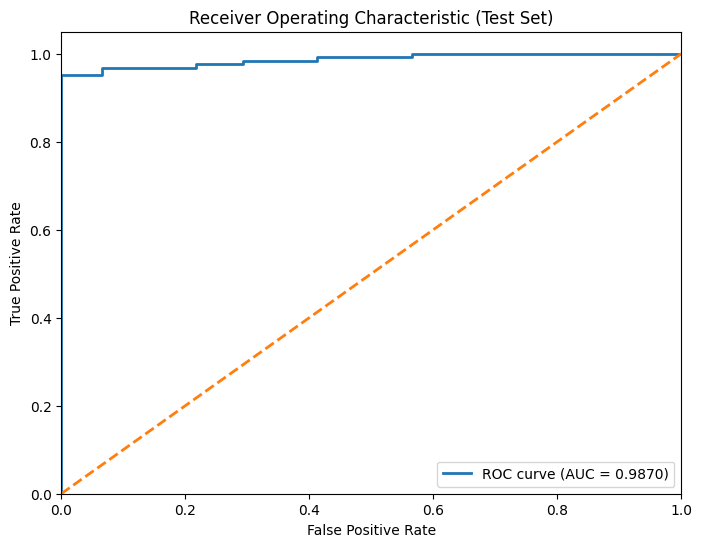


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.93      1.00      0.96        92
         MDD       1.00      0.94      0.97       125

    accuracy                           0.97       217
   macro avg       0.96      0.97      0.97       217
weighted avg       0.97      0.97      0.97       217

Test AUC: 0.9870
Sensitivity (Recall): 0.9440
Specificity: 1.0000


In [ ]:
# ======================================================================================
# CELL 5: Independent Test Set Evaluation and Diagnostic Performance Metrics
# ======================================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import torch
import numpy as np

PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load test set
test_ds = MultimodalDatasetPro(
    csv_path=os.path.join(PROJECT_PATH, 'test_multimodal.csv'),
    augment=False,
    mode='full'
)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)

# Rebuild the same model architecture used in training
class SEBlock3D(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock3D, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _, _ = x.size()
        y = self.fc(self.avg_pool(x).view(b, c)).view(b, c, 1, 1, 1)
        return x * y.expand_as(x)

class MultimodalFusionNetwork(nn.Module):
    def __init__(self):
        super(MultimodalFusionNetwork, self).__init__()

        self.img_encoder = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(16), nn.ReLU(True),
            nn.Conv3d(16, 32, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(32), nn.ReLU(True),
            nn.Conv3d(32, 64, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(64), nn.ReLU(True),
            nn.Conv3d(64, 128, kernel_size=3, stride=2, padding=1), nn.BatchNorm3d(128), nn.ReLU(True)
        )

        self.img_attention = SEBlock3D(128)
        self.img_flatten = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4 * 4, 128),
            nn.ReLU(True)
        )

        self.clin_encoder = nn.Sequential(
            nn.Linear(4, 16), nn.BatchNorm1d(16), nn.ReLU(True),
            nn.Linear(16, 32), nn.BatchNorm1d(32), nn.ReLU(True)
        )

        self.classifier = nn.Sequential(
            nn.Linear(160, 64), nn.BatchNorm1d(64), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, img, clin):
        img_features = self.img_flatten(self.img_attention(self.img_encoder(img)))
        clin_features = self.clin_encoder(clin)
        fused_representation = torch.cat((img_features, clin_features), dim=1)
        return self.classifier(fused_representation)

# Load best trained model
model = MultimodalFusionNetwork().to(DEVICE)
model.load_state_dict(torch.load(os.path.join(PROJECT_PATH, 'best_multimodal_model.pth'), map_location=DEVICE))
model.eval()

all_preds = []
all_labels = []
all_probs = []

print("Phase 5: Generating Final Test Reports...\n")

with torch.no_grad():
    for x_img, x_clin, y in test_loader:
        x_img = x_img.to(DEVICE)
        x_clin = x_clin.to(DEVICE)
        y = y.to(DEVICE)

        outputs = model(x_img, x_clin).view(-1)
        probs = torch.sigmoid(outputs)
        preds = torch.round(probs)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# ROC Curve + AUC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (Test Set)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Healthy', 'MDD']))

# Specificity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp + 1e-8)
sensitivity = tp / (tp + fn + 1e-8)

print(f"Test AUC: {roc_auc:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")